(100, 6)
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')
<bound method NDFrame.head of            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0  -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1  -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2  -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3  -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4  -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
..       ...        ...        ...        ...        ...        ...
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

[100 rows x 6 columns]>
<bound method NDFrame.tail

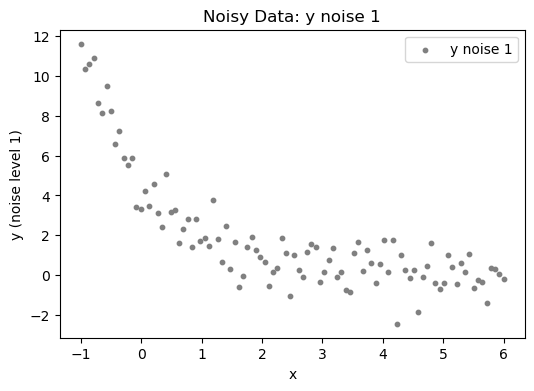

Fit: y = 4.71 * e^(-0.92 * x)
Reduced chi-squared: 0.7907


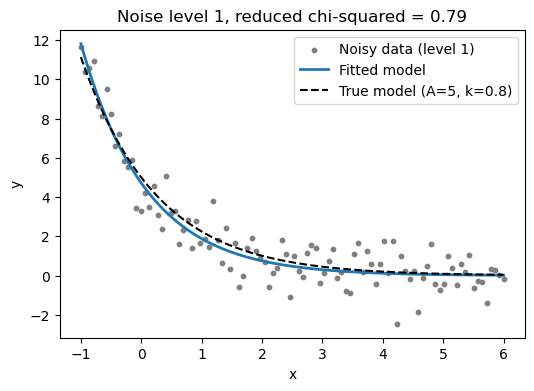

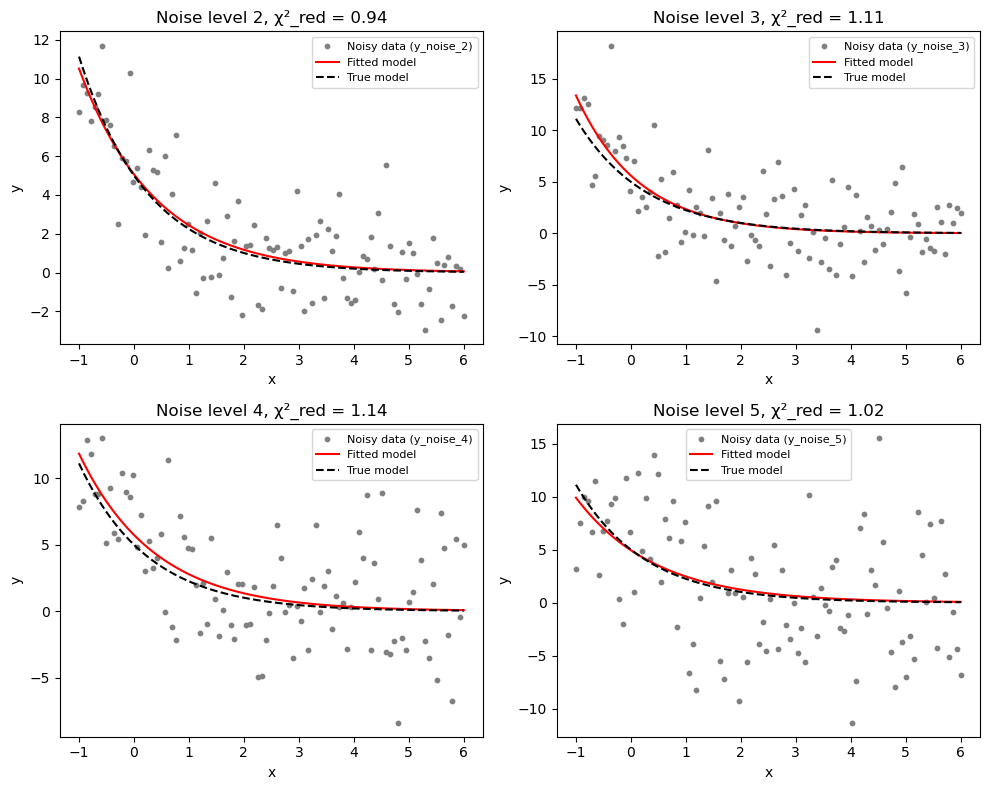

   Noise level     A_fit     k_fit  chi2_reduced
0            1  4.714814  0.918308      0.790673
1            2  5.063889  0.730396      0.935444
2            3  5.609396  0.870372      1.110275
3            4  5.738727  0.725965      1.135896
4            5  4.943458  0.695012      1.017713


In [30]:
# File: homework9

# 2.1: Collect the Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv(r"C:\Users\danie\python_decal_fall25\course_assignments\homework9\noisy_curvefit_data.csv")

# 2.1.4:

print(df.shape) # 100 rows, 6 columns
print(df.columns) # 'x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'
print(df.head)
print(df.tail)

# 2.1.5:

x = df["x"].values
y_noise_1 = df["y_noise_1"].values

plt.figure(figsize = (6,4))
plt.scatter(x, y_noise_1, color="gray", s=10, label="y noise 1")
plt.xlabel("x")
plt.ylabel("y (noise level 1)")
plt.title("Noisy Data: y noise 1")
plt.legend()
plt.show()

# 2.2: Fit the Data

def model(x, A, k):
    return A * np.exp(-k * x)
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

# 2.2.5

residuals = y_noise_1 - model(x, A_fit, k_fit)

chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

print(f"Reduced chi-squared: {chi2_reduced:.4f}")

y_true = model(x, 5.0, 0.8)
y_fit = model(x, A_fit, k_fit)

plt.figure(figsize=(6, 4))
plt.scatter(x, y_noise_1, color="gray", s=10, label="Noisy data (level 1)")
plt.plot(x, y_fit, label="Fitted model", linewidth=2)
plt.plot(x, y_true, linestyle="--", color="black", label="True model (A=5, k=0.8)")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Noise level 1, reduced chi-squared = {chi2_reduced:.2f}")
plt.legend()
plt.show()

# 2.3: Compare Different Noise Levels

def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt

    residuals = y_noise_1 - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    
    return A_fit, k_fit, chi2_reduced

noise_cols = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
results = []

for i, col in enumerate(noise_cols):
    y = df[col].values
    A_fit, k_fit, chi2_red = fit_model(x, y)
    results.append((i+2, A_fit, k_fit, chi2_red))

    ax = axes[i]
    ax.scatter(x, y, color="gray", s=10, label=f"Noisy data ({col})")
    
    y_fit = model(x, A_fit, k_fit)
    ax.plot(x, y_fit, color="red", label="Fitted model")

    y_true = model(x, 5.0, 0.8)
    ax.plot(x, y_true, linestyle="--", color="black", label="True model")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Noise level {i+2}, χ²_red = {chi2_red:.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 2.3.4: As the noise level increases, the points get more scattered across the graph
# The black line stays the same because that is the true model y = 5e^-0.8x
# The red line becomes less and less smooth and deviates more from the true model
# As the noise increased, the difference between the true model and the data gets larger, so chi-squared value gets larger because it is based on the sum of squared residuals.

# 2.4: Save Your Results:

A1, k1, chi2_1 = fit_model(x, y_noise_1)

all_results = []
all_results.append((1, A1, k1, chi2_1))

for (noise_level, A_fit, k_fit, chi2_red) in results:
    all_results.append((noise_level, A_fit, k_fit, chi2_red))

results_df = pd.DataFrame(all_results, columns=["Noise level", "A_fit", "k_fit", "chi2_reduced"])
print(results_df)

results_df.to_csv("noisy_parameters.csv", index=False)
